# CMSE 201: Quiz 4 (Spring 2024)

## <p style="text-align: right;"> &#9989; Put your name here</p>


The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

**If ChatGPT is used**, _you must cite it_ with the access date and the prompt as described in the course [Generative AI policy](https://msu-cmse-courses.github.io/cmse201-S24-jb/Course_Materials-201/AI_Policy/CMSE201_GenerativeAI_Policy.html). Without appropriate citation, you may **receive partial or no credit.**


There are a total of **39 points** possible on this quiz and each part of the quiz can be done independently. **If you get stuck _move on to another part of the quiz to earn some points there!_**


![Moira](https://media.giphy.com/media/26gs78HRO8sOuhTkQ/giphy.gif)

---
<a id="toc"></a>

## Table of Contents

[Part 0. Academic Integrity Statement](#part_0) (1 point)

[Part 1. Curve_fit](#part_1)  (18 points)

[Part 2. Solve_ivp](#part_1)  (20 points)


In [1]:
points_list = [1, 18, 20]

print(f"The total number of points is : {sum(points_list)}")

The total number of points is : 39


### ANSWER (for making sure this gets removed) ###

## Template Guidelines

**Learning Objectives from Homework 3:**
- Using pandas to work with data and clean it
- Make meaningful visual representations of the data
- Tinkering with code
  
**Learning Objectives the Quiz will assess:**
* Loading and manipulating (e.g. filtering, calculating basic statistics) data using Pandas
* Visualizing data and models using matplotlib

**Quiz Duration:** 30 minutes (ideally, time can be extended slightly if needed)
* This means your TAs/LAs should be able to complete the quiz in at most 10 minutes (if TA/LA completion time is closer to 15, consider extending quiz to 40 minutes)

**Notes:**
* The structure and rubric provided here is a suggestion and an example of the difficulty level expected. However, as long as your quiz assesses the learning objectives listed under "Learning Objectives the Quiz will assess" section above, you can differ from this structure. If you aren't sure that your quiz does that, run it by another instructor (lead isntructor, other faculty, TA, or LA)
* The examples provided are examples and **should not be used directly without changes in any quizzes**
* These quizzes are important for students to assess how well they understand the material independent of their groups, so when grading, be sure to provide feedback on where points were deducted. **You should also have a clear rubric with clearly stated point values, but you do not need to follow the point values included in this template**.
* Quizzes should be written with ample time for TAs/LAs to review! **Your TA and LAs should have at least 48 hours to review the quiz before it is given**.
* Quizzes (and instructor solution with point-by-point rubrics) should be **pushed to the GitHub repo for record-keeping**. Put your section's version in a sub-folder with the name `Section-###` where "###" is your section number.

**Overall Structure:**

1. A section that focuses on assessing if students correctly load a CSV file using Pandas and then explores if they have mastered the ability to mask data for the purposes of filtering the data and can calculate basic statistical values.
2. A section that uses some provided data (so as not to penalize them again for not having mastered loading data) and a model function to find the best fit parameters for the model using curve_fit. This question should also assess if they can use those best fit parameters to produce the expected model values and then use matplotlib to visualize their model and compare it to the data.

---
<a id="part_0"></a>

# Part 0. Academic integrity statement (1 points)

[Back to Top](#toc)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

In [7]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import solve_ivp


---
<a id="part_1"></a>

# Part 1. Fitting a model to data with `curve_fit` and visualizing the results (18 points)
[Back to Top](#toc)

We have studied building ordinary differential equations (ODEs) and solving it by `solve_ivp`. Using `curve_fit` to fit the numerical solution can always give us inspiration to find the true solution. In previous assignments, you have used `solve_ivp` to compute the numeric solution of the logistic model of the growth of a single population. Recall, the Logistic population model is described by the following differential equations:

\begin{equation}
\frac{dP}{dt} = kP\Big(1-\frac{P}{C}\Big),
\end{equation}

where $P =$ population, $k =$ growth rate, and $C =$ the carrying capacity. 

Examples code for computing the solution for for $P_0 =0.1$ billion (initial population), $k=1$, and $C =1$ billion is provided below:


Text(0, 0.5, 'p_solution')

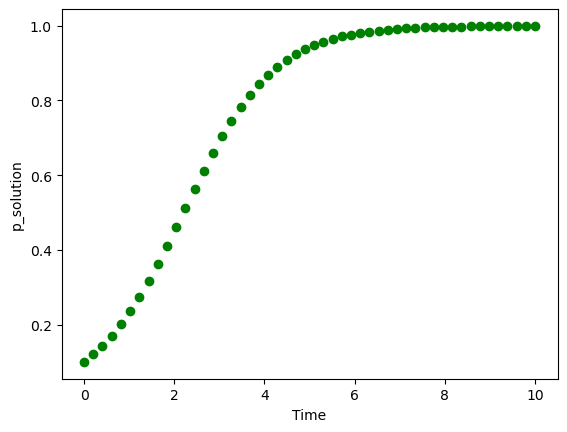

In [8]:
# example code to compute a numeric solution of the logistic model

# define the derivative
def logistic(time, current_state):
    p = current_state   
    dpdt = p*(1-p)    
    return dpdt

# compute numeric solution
initial_p = [0.1]
time = np.linspace(0,10,50)

result = solve_ivp(logistic, (0,20), initial_p, t_eval = time)

# unpack solution
numerical_p = result.y[0,:]

# Make a plot of the result 
fig1 = plt.figure(1)
plt.scatter(time,numerical_p, color="green")
plt.xlabel("Time")
plt.ylabel("p_solution")

---

#### &#9989;&nbsp; **Question 1.1 (8 points):** 

Using the time array `time` and numerical solution `numeriical_p` data and provided model below, use `curve_fit` to find best fit parameters for *a, b,* *c*,and *d*. Make sure you give `curve_fit` a good starting point for finding the best fit parameters using the `p0` argument and these starting values:
* a = 0.1
* b = 3
* c = -0.1
* d = 1



In [9]:
# Will need to use NumPy for the function
import numpy as np

# Will need to import curve_fit from SciPy
from scipy.optimize import curve_fit

# This function calculates volts corresponding to time for a sound wave
def logistic_f(t,a,b,c,d):
    return a/(b*np.exp(c*t)+d)

In [ ]:
# Put your curve_fit code here

In [10]:
### ANSWER
params,ignore = curve_fit(logistic_f,time,numerical_p,p0=[0.1,3,-0.1,1])
print(params)

# rubric
# 2 pts for using model function correctly
# 2 pts for using data correctly
# 2 pts for p0 correct
# 2 pts for printing

[-3.30182640e-04 -2.97289031e-03 -1.00047944e+00 -3.30179915e-04]


&#9989;&nbsp; **Part 1.2 (10 points)**

Now that you have a set of best fit parameters, **use those parameters to calculate the expected model values and plot the expected model values on top of the actual data values**. Make sure to label your axes and include a legend to communicate what parts of the plot correspond to the model versus the data.

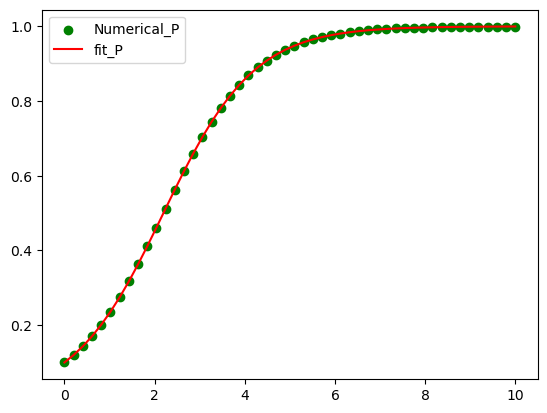

In [11]:
### ANSWER ###
plt.scatter(time,numerical_p,color = 'g',label='Numerical_P')
plt.plot(time,logistic_f(time,params[0],params[1],params[2],params[3]),color = 'r',label='fit_P')
plt.legend()

# Rubric
# 5 pts for data and best fit
# 5 pts for labels, legend, etc.

---
## Part 2: Modeling a system using `solve_ivp` (20 points)

Now you wonder: what happens if there are two different species competing for the same resources? (Such as the great white sharks and the seven-gill sharks &#x1F609;) How would the population growth of one species interfere with that of the other? 

Luckily, such models already exist. One of them is a generalization of the logistic model to take into account resource competition between two species $u$ and $v$ and we have the following competitive Lotka-Volterra model:

$$ \frac{du}{dt} = r_1u(1-(\frac{u +a_{12} v}{K_1}))$$
$$ \frac{dv}{dt} = r_2v(1 -(\frac{v + a_{21}u}{K_2})).$$

Here, $a_{12}$ represents the competitive effect species $v$ has on the population of species $u$ and $a_{21}$ represents the competitive effect species u has on the population of species v. These values do not have to be equal. Because this is the competitive version of the model, all interactions must be harmful (competition) and therefore all a-values are positive.

After scaling, the **two species competitive Lotka-Volterra model** can become to the simplified case:
\begin{align}
\frac{du}{dt} &= u(1-u -\alpha v)  &(1)\\
\frac{dv}{dt} &= rv(1 -v-\beta u). &(2)
\end{align}

We say that the competition on the species u (resp.
on the species v) is **strong** if $\alpha > 1$ (resp. $\beta > 1$).We say that the competition on the species
u (resp. on the species v) is **weak** if $0 < \alpha < 1$ (resp. $0 < \beta< 1$). 

**Your job for this part is implementing and computing the numeric solutions for the two species competitive Lotka-Volterra model as described by equations 1 and 2 above. You can do so by adapting the code for the logistic model above.**

&#9989;&nbsp; **Part 2.1 (8 points)**  
Define the derivative function for the two species competitive Lotka-Volterra model in the cell below (to be used as an input later for `solve_ivp` -- so pay attention to the format).

In [ ]:
# write your function here

In [13]:
### ANSWER
def CLV(time, current_state, alpha, beta, r):
    
    u = current_state[0]
    v = current_state[1]
    
    du_dt = u*(1-u-alpha*v)
    dv_dt = r*v*(1-beta*u -v)
    
    return [du_dt, dv_dt]

## rubric
# 2 pts for any attempt at defining a function
# 2 pts for getting input argument positions correct
# 1 pt for unpacking current_state correctly
# 1 pt for returning du dv correctly
# 2 pts for defining the equations correctly

&#9989;&nbsp; **Part 2.2 (6 points)**

Using `solve_ivp`, compute the numeric solution for two species competitive Lotka-Volterra model with the parameters $r=1$, $\alpha=1/3,$ $\beta =3/4$, the initial conditions $[u_0,v_0]= [0.5,0.9]$, and the final time equal 30. Unpack the result you get from `solve_ivp` into separate variables `u` and `v`.

In [23]:
### ANSWER
alpha = 1/3
beta = 3/4
r = 1
initial_conditions = [0.5,0.9]
time = np.linspace(0,30,1000)

result = solve_ivp(CLV, (0,30),initial_conditions, t_eval = time, args=(alpha, beta, r))

u = result.y[0,:]
v = result.y[1,:]

## Rubric
# 2 pts for defining parameters and initial conditions correctly
# 1 pt for defining time array
# 2 pts for calling solve_ivp correctly
# 1 pt for unpacking the results

&#9989;&nbsp; **Part 2.3 (4 points)**

Plot the solutions of $u$ and $v$ as a function of time in the cell below. Be sure to add appropriate axis labels and legends. 

Text(0.5, 1.0, 'Solution of the weak-weak competitive Lotka-Volterra equations')

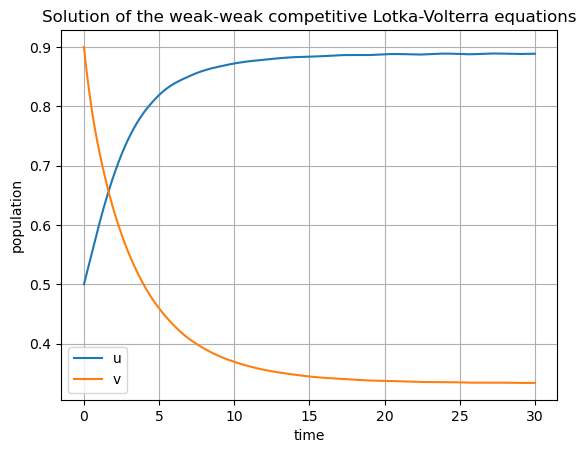

In [24]:
### ANSWER
import matplotlib.pyplot as plt

plt.plot(time, u, label='u')
plt.plot(time, v, label='v')
plt.grid()
plt.legend()
plt.xlabel('time')
plt.ylabel('population')
plt.title('Solution of the weak-weak competitive Lotka-Volterra equations')

## Rubric
# 2 pts for plotting the two lines correctly
# 2 pts for axis labels and legends

&#9989;&nbsp; **Part 2.4 (2 points)**

When $0 < \alpha,\beta <1$, we call the model a weak competitive Lotka-Volterra model. Check with the plot above to see what will happen as time goes on. Can the two species, i.e. $u$ and $v$, coexist or one species will die out?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### ANSWER
The two species will coexist together. (2 points)

---

# Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  

Go to the **Quizzes** section, find the submission folder link for **Quiz 04**, and upload it there.


![Moira2](https://media.giphy.com/media/d1E2HnwywoTkES08/giphy.gif)